# Telco Customer Churn Analysis and Prediction 

This project explores customer churn behavior in a telecommunications company using exploratory data analysis (EDA) and machine learning techniques.

The analysis focuses on identifying factors associated with customer churn and building predictive models to classify customers who are likely to leave the service.

The project includes:

- Customer churn distribution analysis
- Demographic and contract-based analysis
- Monthly charges and tenure analysis
- Data preprocessing and feature engineering
- Logistic Regression, Decision Tree, and Random Forest models
- Model evaluation using classification metrics
- ROC curve and AUC score analysis
- Business insights for customer retention strategies

## Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

The following libraries were imported for data preprocessing, exploratory data analysis, visualization, machine learning modeling, and model evaluation.

## Upload Dataset

The Telco Customer Churn dataset was loaded into a pandas DataFrame for preprocessing, exploratory data analysis, and machine learning modeling.

In [2]:
df = pd.read_csv("telco_customer_churn.csv")


## Dataset Overview

An initial overview of the dataset was performed to examine customer-related variables, data types, numerical distributions, and overall dataset structure before preprocessing and analysis.

The first few rows of the dataset were displayed to understand the overall structure, customer attributes, and churn-related variables.

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Most variables are categorical and stored as object data types, while MonthlyCharges is already in numerical format.

The TotalCharges variable was incorrectly loaded as an object type and requires numeric conversion during preprocessing.

In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


The average customer tenure is approximately 32 months, although customer durations vary significantly across the dataset.
Monthly charges also show substantial variation, reflecting differences in subscribed services and customer billing behavior. 

## Data Cleaning and Type Conversion

Certain variables required preprocessing and type conversion before analysis and machine learning modeling.

In particular, the TotalCharges variable was stored as an object data type due to formatting inconsistencies and blank string values. Numeric conversion was applied to ensure proper statistical analysis and modeling compatibility.

In [6]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

Invalid or non-numeric entries were automatically converted into missing values during preprocessing using errors="coerce".

## Missing Value Analysis

In [7]:
df.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

Missing value analysis revealed 11 missing observations in the TotalCharges variable after numeric conversion.

These missing values originated from blank string entries that could not be converted into numerical format during preprocessing.

## Missing Value Handling

In [8]:
df = df.dropna(subset=["TotalCharges"])

In [9]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

The dataset became fully complete after handling missing values, making it suitable for exploratory analysis and machine learning applications.

## Churn Distribution Analysis

In [10]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [11]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64

Approximately 26.6% of customers have churned, while 73.4% remained with the company.

Although the dataset exhibits a moderate class imbalance, the churn rate remains substantial. This highlights customer retention as an important business challenge and supports the need for predictive churn modeling.

## Exploratory Data Analysis

## Customer Tenure Analysis

In [12]:
df.groupby("Churn")["tenure"].mean()

Churn
No     37.650010
Yes    17.979133
Name: tenure, dtype: float64

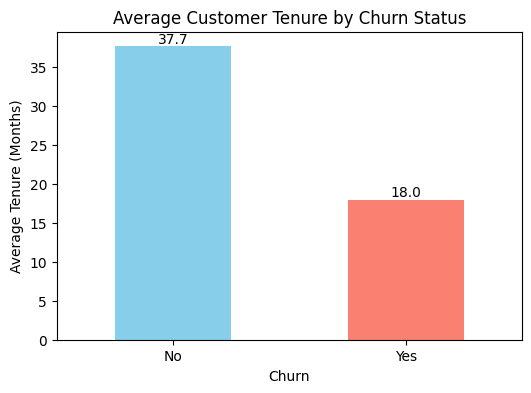

In [13]:
ax = df.groupby("Churn")["tenure"].mean().plot(
    kind="bar",
    color=["skyblue", "salmon"],
    figsize=(6,4)
)

plt.title("Average Customer Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Average Tenure (Months)")
plt.xticks(rotation=0)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}",
        (
            p.get_x() + p.get_width() / 2,
            p.get_height()
        ),
        ha="center",
        va="bottom"
    )

Customers who churned stayed with the company for an average of only 18 months, while retained customers remained for nearly 38 months on average.

This suggests that newer customers are significantly more likely to leave the company. The findings highlight the importance of early-stage customer retention strategies and long-term customer engagement.

## Monthly Charges Analysis

In [14]:
avg_charge = df.groupby(by="Churn")["MonthlyCharges"].mean()
avg_charge

Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64

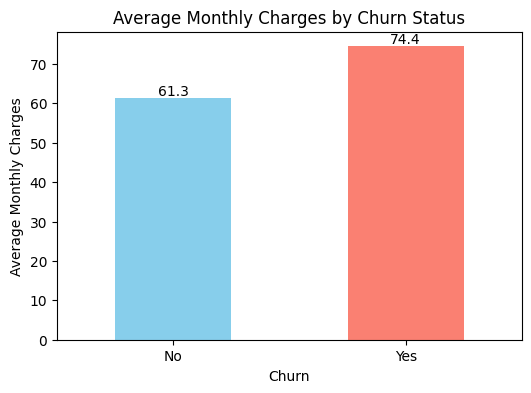

In [15]:
ax = df.groupby("Churn")["MonthlyCharges"].mean().plot(
    kind="bar",
    color=["skyblue", "salmon"],
    figsize=(6,4)
)

plt.title("Average Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Average Monthly Charges")
plt.xticks(rotation=0)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}",
        (
            p.get_x() + p.get_width() / 2,
            p.get_height()
        ),
        ha="center",
        va="bottom"
    )

Customers who churned had noticeably higher average monthly charges compared to retained customers.

This suggests that higher service costs may contribute to customer dissatisfaction and increase the likelihood of churn. Pricing strategy and perceived service value may therefore play an important role in customer retention.

### Contract Type Analysis

In [16]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
)*100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


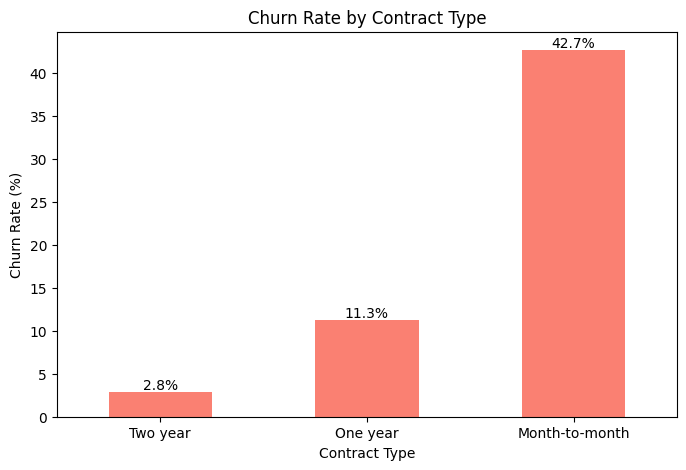

In [17]:
ax = contract_churn["Yes"].sort_values().plot(
    kind="bar",
    figsize=(8,5),
    color = "salmon"
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (
            p.get_x() + p.get_width()/2,
            p.get_height() + 0.3
        ),
        ha="center"
    )

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation = 0)
plt.show()

Customers with month-to-month contracts exhibited the highest churn rate, with approximately 42.7% leaving the company.

In contrast, customers with one-year and especially two-year contracts showed significantly lower churn rates. These findings suggest that longer contractual commitments play a major role in improving customer retention and reducing churn risk.

####  Payment Method Analysis

In [18]:
payment_churn = pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
)*100

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


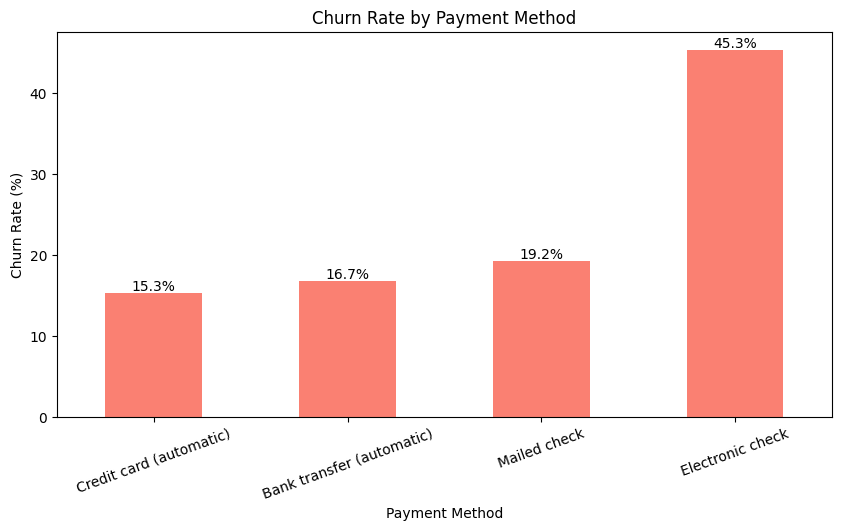

In [19]:
ax = payment_churn["Yes"].sort_values().plot(
    kind="bar",
    figsize=(10,5),
    color = "salmon"
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (
            p.get_x() + p.get_width()/2,
            p.get_height() + 0.3
        ),
        ha="center"
    )
    

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation = 20)
plt.show()

Customers using electronic check as their payment method showed the highest churn rate, with approximately 45.3% leaving the company.

In contrast, customers using automatic payment methods such as bank transfer and credit card exhibited significantly lower churn rates. These findings suggest that automated payment systems may contribute to improved customer retention and reduced churn risk.

### Internet Service Analysis

In [20]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
)*100

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


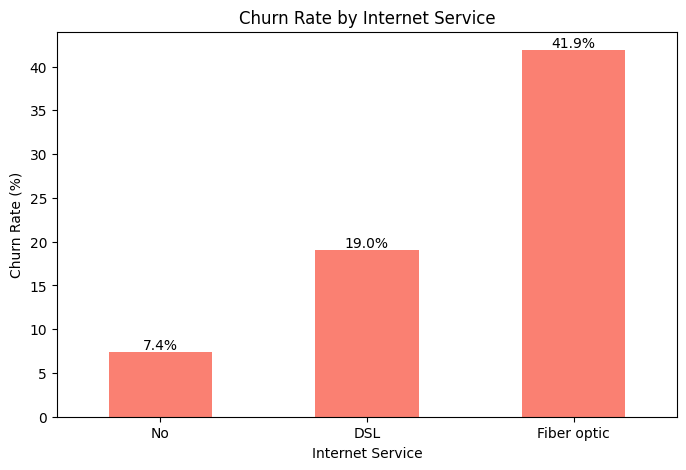

In [21]:
ax = internet_churn["Yes"].sort_values().plot(
    kind="bar",
    figsize=(8,5),
    color = "salmon"
)


for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (
            p.get_x() + p.get_width()/2,
            p.get_height() + 0.3
        ),
        ha="center"
    )
plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation = 0)
plt.show()

Customers using fiber optic internet service exhibited the highest churn rate, with approximately 41.9% leaving the company.

Customers without internet service showed the lowest churn rate, while DSL customers experienced moderate churn levels. These findings may suggest that fiber optic customers face higher pricing concerns, service expectations, or service-related dissatisfaction.

#### Tech Support Analysis

In [22]:
tech_churn = pd.crosstab(
    df["TechSupport"],
    df["Churn"],
    normalize="index"
)*100

tech_churn

Churn,No,Yes
TechSupport,,
No,58.352535,41.647465
No internet service,92.565789,7.434211
Yes,84.803922,15.196078


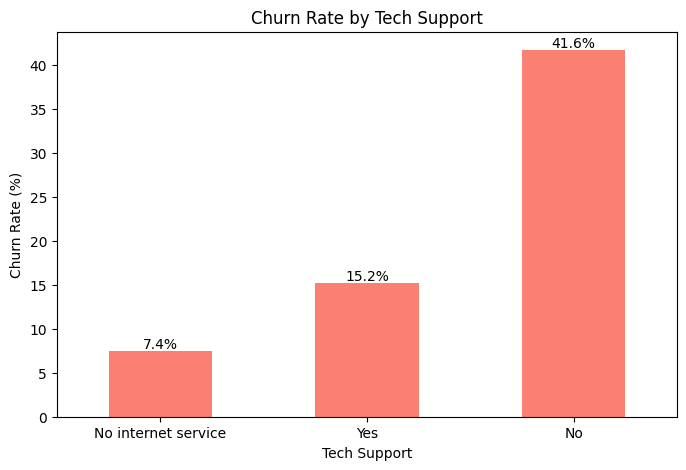

In [23]:
ax = tech_churn["Yes"].sort_values().plot(
    kind="bar",
    figsize=(8,5),
    color = "salmon"
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (
            p.get_x() + p.get_width()/2,
            p.get_height() + 0.3
        ),
        ha="center"
    )

plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation = 0)
plt.show()

Customers without technical support exhibited the highest churn rate, with approximately 41.6% leaving the company.

In contrast, customers who received technical support showed substantially lower churn rates. This suggests that access to reliable customer support services may play a critical role in improving customer satisfaction, resolving service-related issues, and reducing churn risk.

#### Online Security Analysis

In [24]:
security_churn = pd.crosstab(
    df["OnlineSecurity"],
    df["Churn"],
    normalize="index"
)*100

security_churn

Churn,No,Yes
OnlineSecurity,,
No,58.221333,41.778667
No internet service,92.565789,7.434211
Yes,85.359801,14.640199


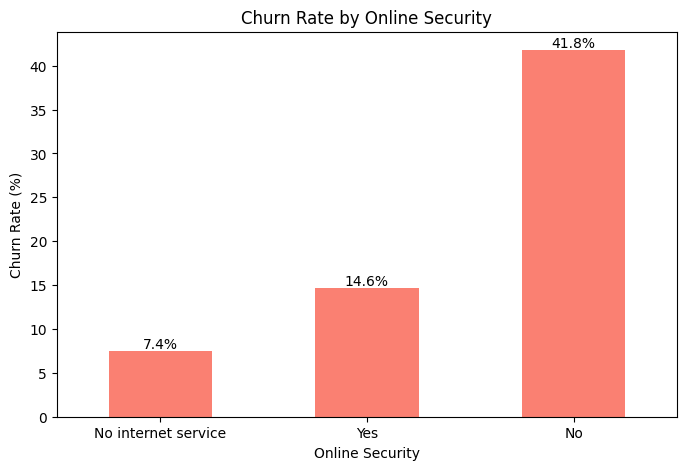

In [25]:
ax = security_churn["Yes"].sort_values().plot(
    kind="bar",
    figsize=(8,5),
    color = "salmon"
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (
            p.get_x() + p.get_width()/2,
            p.get_height() + 0.3
        ),
        ha="center"
    )

plt.title("Churn Rate by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation = 0)
plt.show()

Customers without online security services exhibited the highest churn rate, with approximately 41.8% leaving the company.

In contrast, customers subscribed to online security services showed substantially lower churn rates. These findings suggest that customers who receive additional security-related services may feel more satisfied, secure, and engaged with the company, leading to improved customer retention.

### Paperless Billing Analysis

In [26]:
paperless_churn = pd.crosstab(
    df["PaperlessBilling"],
    df["Churn"],
    normalize="index"
)*100

paperless_churn

Churn,No,Yes
PaperlessBilling,,
No,83.624302,16.375698
Yes,66.410749,33.589251


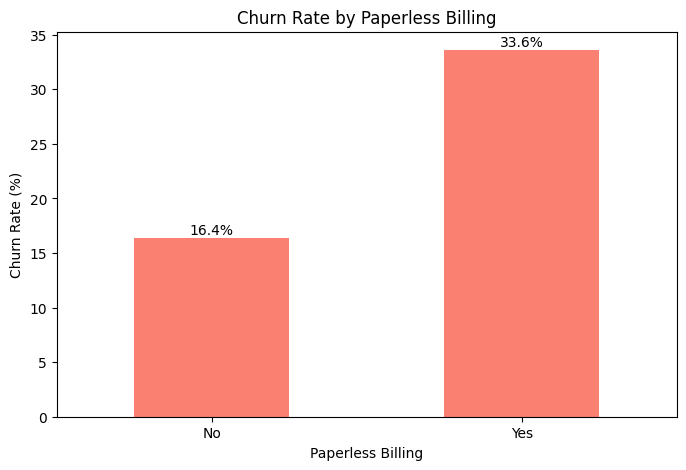

In [27]:
ax = paperless_churn["Yes"].sort_values().plot(
    kind="bar",
    figsize=(8,5),
    color = "salmon"
)


for p in ax.patches:
    ax.annotate(
        f"{p.get_height():.1f}%",
        (
            p.get_x() + p.get_width()/2,
            p.get_height() + 0.3
        ),
        ha="center"
    )

plt.title("Churn Rate by Paperless Billing")
plt.xlabel("Paperless Billing")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation = 0)
plt.show()

Customers using paperless billing exhibited a noticeably higher churn rate compared to customers receiving traditional billing methods.
This may suggest that digitally engaged customers are more likely to switch providers due to lower switching barriers and greater market flexibility.

### Monthly Charges Distribution 

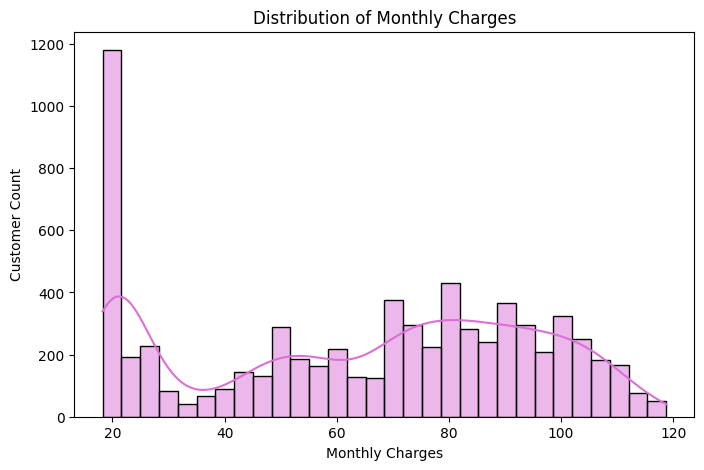

In [28]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="MonthlyCharges",
    bins=30,
    kde=True,
    color="orchid"
)

plt.title("Distribution of Monthly Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Customer Count")

plt.show()


Monthly charges are distributed across a wide range, although a noticeable concentration exists at lower pricing levels. This suggests that the company serves customers with different service packages and pricing structures.

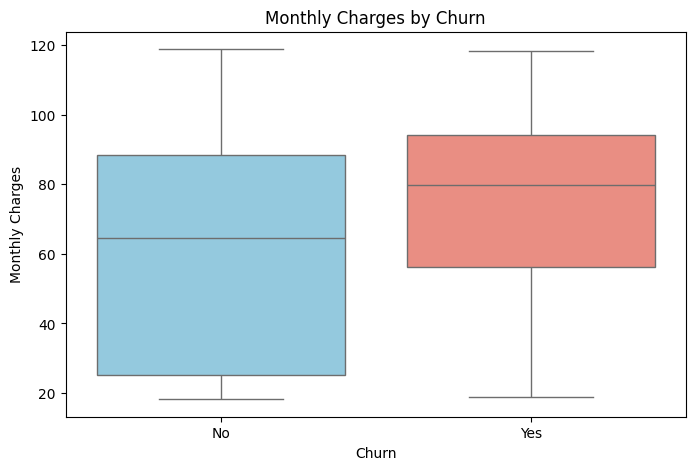

In [29]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges",
    hue="Churn",
    palette=["skyblue", "salmon"],
    legend=False
)

plt.title("Monthly Charges by Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

Customers who churned generally exhibited higher monthly charges compared to retained customers. The distribution suggests that higher service costs may increase churn risk and customer dissatisfaction.

### Correlation Analysis

In [30]:
numeric_df = df.select_dtypes(include=["int64","float64"])

numeric_df.corr()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.015683,0.219874,0.102411
tenure,0.015683,1.000000,0.246862,0.825880
MonthlyCharges,0.219874,0.246862,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


#### Correlation Matrix

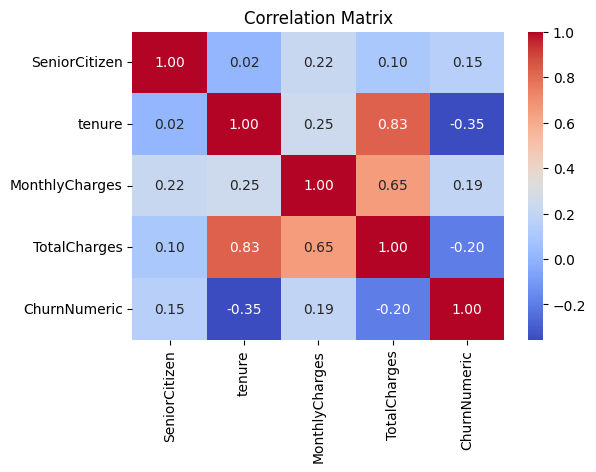

In [32]:
df["ChurnNumeric"] = df["Churn"].map({
    "No":0,
    "Yes":1
})

numeric_df = df.select_dtypes(include=["int64", "float64"])


plt.figure(figsize=(6,4))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

The correlation analysis revealed that customer tenure had the strongest relationship with churn, showing a moderate negative correlation (-0.35). This suggests that customers who remain with the company for longer periods are less likely to leave. MonthlyCharges exhibited a weak positive correlation (0.19) with churn, indicating that higher monthly costs may be associated with a slightly increased churn risk. Overall, the relatively low correlation coefficients suggest that customer churn is influenced by multiple factors rather than a single variable.

### Data Preprocessing

In [33]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
ChurnNumeric          int64
dtype: object

### Feature Encoding

In [34]:
df = df.drop("customerID", axis=1)

The customerID variable was removed because it does not contain predictive behavioral information for churn modeling.

### One-Hot Encoding

Categorical variables cannot be directly interpreted by most machine learning algorithms. Therefore, one-hot encoding was applied to transform categorical features into numerical binary variables.

In [35]:
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,ChurnNumeric,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,True,False,True,False,True


In [36]:
df_encoded.shape

(7032, 32)

The dimensionality of the dataset increased after one-hot encoding, as categorical variables were transformed into multiple binary indicator features.

In [37]:
X = df_encoded.drop(["Churn_Yes","ChurnNumeric"], axis=1)

y = df_encoded["Churn_Yes"]

In [38]:
print("Feature Matrix Shape:", X.shape)
print("Target Variable Shape:", y.shape)

Feature Matrix Shape: (7032, 30)
Target Variable Shape: (7032,)


### Train-Test Split

The dataset was divided into training and testing sets to evaluate model performance on unseen data.
This split helps prevent overfitting and enables a more reliable evaluation of machine learning models.

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Logistic Regression Model

Feature scaling was applied to standardize numerical variables before model training.
Scaling helps logistic regression converge more efficiently and prevents variables with large ranges from dominating the model.

In [40]:
scaler = StandardScaler()

In [41]:
X_train_scaled = scaler.fit_transform(X_train)

In [42]:
X_test_scaled = scaler.transform(X_test)

In [43]:
log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

log_model.fit(X_train_scaled,y_train)

log_y_pred = log_model.predict(X_test_scaled)

log_accuracy = accuracy_score(y_test,log_y_pred)
print("Accuracy:", log_accuracy)

log_cls = classification_report(y_test,log_y_pred)
print("Classification:",log_cls)


Accuracy: 0.7313432835820896
Classification:               precision    recall  f1-score   support

       False       0.90      0.71      0.80      1033
        True       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407



The Logistic Regression model achieved an overall accuracy of 78.5%. The model performed strongly in identifying non-churn customers, with a recall of 90% and an F1-score of 0.86. For churn customers, the model achieved a precision of 63%, recall of 48%, and an F1-score of 0.54. These results indicate that the model is more effective at predicting customers who remain with the company than customers who leave. While overall performance is reasonable, further improvements may be needed to increase churn detection performance.

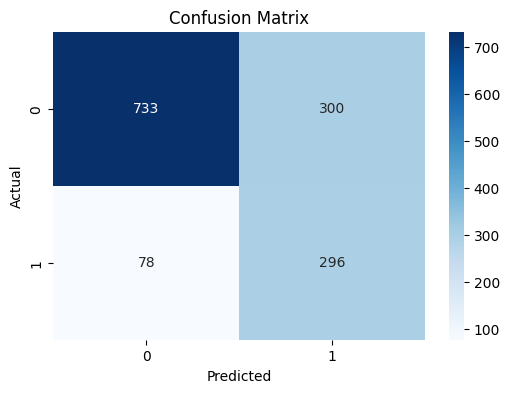

In [44]:
cm_log = confusion_matrix(y_test,log_y_pred)
cm_log

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_log,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

The confusion matrix shows that the Logistic Regression model correctly classified 733 non-churn customers and 296 churn customers.However, 300 non-churn customers were incorrectly predicted as churn, while 78 churn customers were misclassified as non-churn. The model demonstrates a strong ability to identify customers at risk of churn while maintaining a relatively low number of false negatives. From a business perspective, this trade-off may be acceptable because failing to identify a potential churn customer can be more costly than incorrectly flagging a loyal customer as being at risk.

### Random Forest Classifier

In [45]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train,y_train)

rf_y_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test,rf_y_pred)
print("Accuracy:", rf_accuracy)

rf_cls = classification_report(y_test,rf_y_pred)
print("Classification:",rf_cls)


Accuracy: 0.7853589196872779
Classification:               precision    recall  f1-score   support

       False       0.83      0.90      0.86      1033
        True       0.63      0.48      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



The Logistic Regression model achieved an overall accuracy of 78.5%. The model performed well in identifying customers who remained with the company, achieving a recall of 90% for the non-churn class. However, its performance in detecting churn customers was more limited, with a recall of 48%.

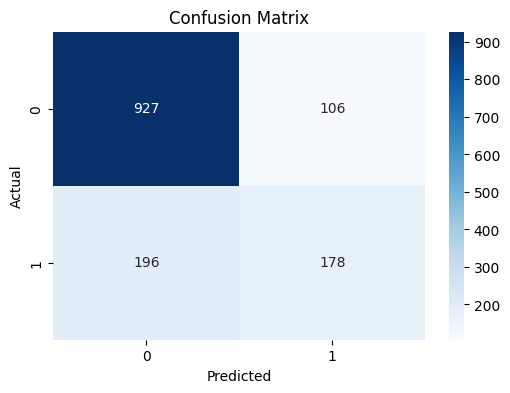

In [46]:
rf_cm = confusion_matrix(y_test,rf_y_pred)
rf_cm

plt.figure(figsize=(6,4))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

The confusion matrix shows that the model correctly classified 927 non-churn customers and 178 churn customers, while missing 196 actual churn customers.These results indicate that the model favors the majority class and may not be sufficiently effective for customer retention scenarios where identifying potential churn customers is a priority.

### Desicion Tree Model 

In [47]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train,y_train)

dt_y_pred = dt_model.predict(X_test)


dt_accuracy = accuracy_score(y_test,dt_y_pred)
print("Accuracy:", dt_accuracy)

dt_cls = classification_report(y_test,dt_y_pred)
print("Classification:",dt_cls)


Accuracy: 0.7249466950959488
Classification:               precision    recall  f1-score   support

       False       0.82      0.80      0.81      1033
        True       0.48      0.52      0.50       374

    accuracy                           0.72      1407
   macro avg       0.65      0.66      0.66      1407
weighted avg       0.73      0.72      0.73      1407



The Decision Tree model achieved an accuracy of 72%. The recall score for the churn class was 52%, showing a moderate ability to detect customers at risk of leaving. While the model slightly improved churn detection compared to some baseline approaches, its overall performance suggests that additional optimization or more advanced models may be required to improve customer churn identification.

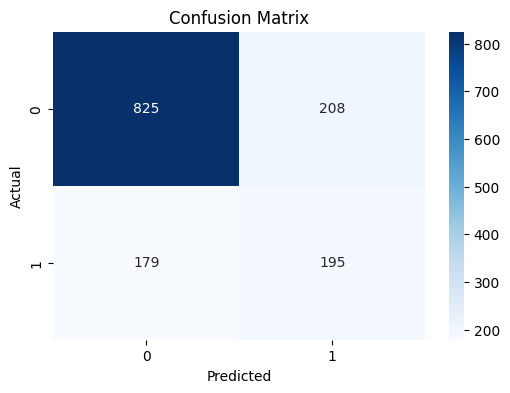

In [48]:
dt_cm = confusion_matrix(y_test,dt_y_pred)
dt_cm

plt.figure(figsize=(6,4))

sns.heatmap(
    dt_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

The model correctly identified 825 non-churn customers and 195 churn customers. However, 179 churn customers were incorrectly classified as non-churn, indicating that nearly half of the customers who actually left the company were missed by the model.

### Model Comparison

Model performance was compared using accuracy, precision, recall, and F1-score. Since customer churn prediction focuses on identifying customers at risk of leaving, recall was considered the most important evaluation metric.

In [49]:
comparison_df = pd.DataFrame({
    "Model": [
        "Balanced Logistic Regression",
        "Random Forest",
        "Decision Tree"
    ],
    "Accuracy": [
        0.73,
        0.79,
        0.72
    ],
    "Precision": [
        0.50,
        0.63,
        0.48
    ],
    "Recall": [
        0.79,
        0.48,
        0.52
    ],
    "F1-Score": [
        0.61,
        0.54,
        0.50
    ]
})

comparison_df.round(2)

comparison_df = comparison_df.sort_values(
    by="Recall",
    ascending=False
)

comparison_df.style.highlight_max(
    subset=["Accuracy","Precision","Recall","F1-Score"],
    color="#760D66"
)

,Model,Accuracy,Precision,Recall,F1-Score
0,Balanced Logistic Regression,0.730000,0.500000,0.790000,0.610000
2,Decision Tree,0.720000,0.480000,0.520000,0.500000
1,Random Forest,0.790000,0.630000,0.480000,0.540000


Model comparison results showed that Random Forest achieved the highest overall accuracy (79%) and precision (63%). However, its recall for churn customers remained relatively low (48%), indicating that many customers who actually left the company were not identified.
Balanced Logistic Regression achieved the highest recall (79%) and F1-score (61%), demonstrating a stronger ability to detect potential churn customers. Since customer retention projects prioritize identifying customers at risk of leaving, Balanced Logistic Regression was considered the most suitable model despite its lower overall accuracy.

### ROC Curve and AUC Analysis

The ROC curve was used to evaluate the classification performance of the final Balanced Logistic Regression model across different decision thresholds. The Area Under the Curve (AUC) score provides a summary measure of the model's ability to distinguish between customers who churn and those who remain with the company.

In [50]:
y_prob = log_model.predict_proba(X_test_scaled)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

AUC Score: 0.8316284535463399


The Balanced Logistic Regression model achieved an ROC-AUC score of 0.83, indicating a strong ability to distinguish between customers who are likely to churn and those who are likely to remain with the company.

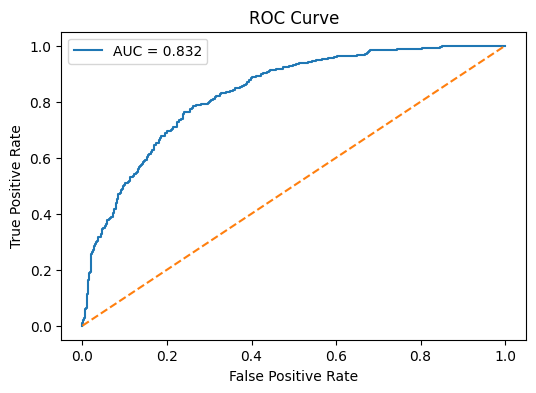

In [51]:
plt.figure(figsize=(6,4))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

The ROC curve remains well above the diagonal baseline, demonstrating that the model performs substantially better than random guessing across different classification thresholds. This result suggests that the model can effectively rank customers according to their churn risk and provides reliable support for customer retention initiatives.

### Most Influential Features

In [52]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient":log_model.coef_[0]
})

feature_importance["Abs_Coefficient"] = abs(
    feature_importance["Coefficient"]
)

feature_importance = feature_importance.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

feature_importance.head(10)


,Feature,Coefficient,Abs_Coefficient
1,tenure,-1.354457,1.354457
2,MonthlyCharges,-0.872060,0.872060
10,InternetService_Fiber optic,0.733778,0.733778
3,TotalCharges,0.657752,0.657752
25,Contract_Two year,-0.606754,0.606754
24,Contract_One year,-0.328937,0.328937
23,StreamingMovies_Yes,0.263129,0.263129
21,StreamingTV_Yes,0.258066,0.258066
9,MultipleLines_Yes,0.162098,0.162098
28,PaymentMethod_Electronic check,0.139128,0.139128


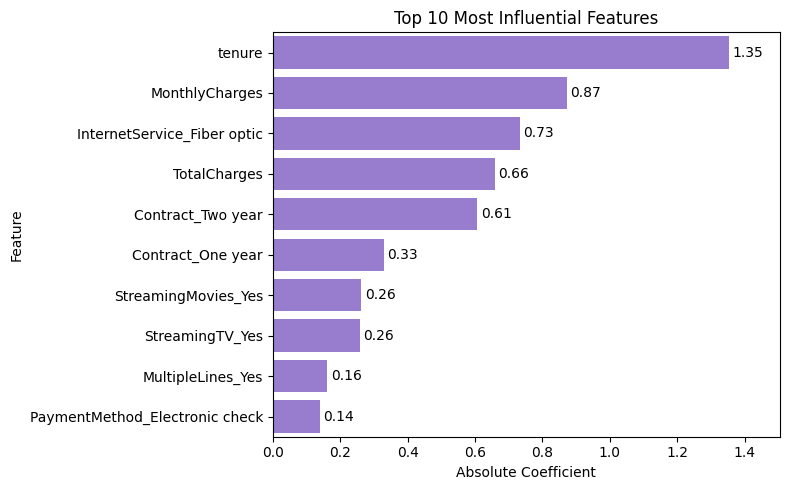

In [53]:
top_features = feature_importance.head(10)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=top_features,
    x="Abs_Coefficient",
    y="Feature",
    color="mediumpurple"
)

for p in ax.patches:
    ax.annotate(
        f"{p.get_width():.2f}",
        (
            p.get_width() + 0.01,
            p.get_y() + p.get_height()/2
        ),
        va="center"
    )

ax.set_xlim(
    0,
    top_features["Abs_Coefficient"].max() + 0.15
)

plt.title("Top 10 Most Influential Features")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

The analysis revealed that tenure was the most influential predictor of customer churn, followed by Monthly Charges, Internet Service Type, Total Charges, and Contract Type. The results suggest that customer loyalty and contract commitment play a significant role in reducing churn risk. Customers with shorter tenure and higher monthly charges were more likely to leave the company, while longer-term contracts were associated with lower churn rates. Additionally, internet service type emerged as an important factor, indicating that service-related characteristics may influence customer retention behavior. Overall, the findings highlight the importance of customer retention strategies focused on early customer engagement, pricing policies, and long-term contract incentives.

## Conclusion 

This project explored customer churn behavior using exploratory data analysis and machine learning techniques. The analysis revealed that churn rates were particularly high among customers with month-to-month contracts, fiber optic internet services, electronic check payment methods, and higher monthly charges. In contrast, customers with longer tenure and long-term contracts exhibited lower churn rates.

Among the evaluated models, Balanced Logistic Regression provided the most suitable business performance by achieving the highest recall (79%), allowing the model to identify the majority of customers at risk of churn. Since customer retention is a key business objective, minimizing false negatives was prioritized over maximizing overall accuracy.

Coefficient analysis indicated that tenure, monthly charges, internet service type, total charges, and contract type were among the most influential factors associated with churn behavior. Overall, the findings highlight the importance of customer loyalty, pricing strategy, and contractual commitment in reducing customer attrition.

##  Business Recommendations

- Encourage customers to switch from month-to-month contracts to longer-term contracts through loyalty programs and promotional offers.
- Investigate the causes of high churn among fiber optic internet users and improve service quality where necessary.
- Monitor customers with high monthly charges and provide personalized retention campaigns before churn occurs.
- Use the Balanced Logistic Regression model as an early warning system to identify high-risk customers and implement proactive retention strategies.